# Visualisation des postérieurs

Ce notebook charge un postérieur `.npz`, retrouve automatiquement son pendant réel ou reconstruit, puis produit les quatre figures de diagnostic.

In [1]:
from pathlib import Path

import corner
import h5py
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

%matplotlib inline

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "font.size": 11,
})

BLUE = "#2563EB"
RED = "#DC2626"
COLORS = {"real": BLUE, "reconstructed": RED}
LABELS = [
    r"$f_0-f_{0,\mathrm{true}}$ [$\mu$Hz]",
    r"$\dot f$ [$10^{-15}$ Hz s$^{-1}$]",
    r"$\sin\beta$",
    r"$\lambda$ [rad]",
    r"$A$ [$10^{-22}$]",
    r"$\cos\iota$",
]

## Configuration

Il suffit de modifier `POSTERIOR_PATH`. Le chemin peut pointer vers le fichier réel **ou** reconstruit. `BURN_IN` est exprimé en nombre d'itérations MCMC, pas en nombre d'échantillons aplatis.

In [2]:
POSTERIOR_PATH = Path("posterior/posteriors_snr_high_quality_3_real.npz")
BURN_IN = 0
H5_PATH = Path("reconstructed_waveform.h5")
MAX_CORNER_SAMPLES = 50_000

In [3]:
def companion_paths(selected_path):
    selected_path = Path(selected_path)
    if selected_path.suffix == ".npy":
        raise ValueError(
            "Les anciens fichiers .npy ne contiennent ni les traces ni les "
            "log-vraisemblances. Relancez run_mcmc.py pour créer les .npz."
        )
    if selected_path.name.endswith("_real.npz"):
        companion = selected_path.with_name(
            selected_path.name.replace("_real.npz", "_reconstructed.npz")
        )
    elif selected_path.name.endswith("_reconstructed.npz"):
        companion = selected_path.with_name(
            selected_path.name.replace("_reconstructed.npz", "_real.npz")
        )
    else:
        raise ValueError("Le nom doit finir par _real.npz ou _reconstructed.npz.")
    for path in (selected_path, companion):
        if not path.exists():
            raise FileNotFoundError(path)
    return selected_path, companion


def load_pair(selected_path):
    posteriors = {}
    for path in companion_paths(selected_path):
        with np.load(path) as archive:
            item = {key: archive[key] for key in archive.files}
        kind = str(item["source_kind"].item())
        posteriors[kind] = item
    if set(posteriors) != {"real", "reconstructed"}:
        raise ValueError("La paire réelle/reconstruite est incomplète.")
    real = posteriors["real"]
    reconstructed = posteriors["reconstructed"]
    for key in ("element_index", "source_number"):
        if real[key].item() != reconstructed[key].item():
            raise ValueError(f"Métadonnée incompatible : {key}")
    return posteriors


def load_source_info(h5_path, element_index, source_number):
    with h5py.File(h5_path, "r") as h5_file:
        matches = np.flatnonzero(
            (h5_file["element_index"][:] == element_index)
            & (h5_file["source_number"][:] == source_number)
        )
        if len(matches) != 1:
            raise ValueError(f"Source HDF5 introuvable ou ambiguë : {matches}")
        index = int(matches[0])
        return {
            "source_real": h5_file["source_real"][index],
            "source_reconstructed": h5_file["source_reconstructed"][index],
            "snr": float(h5_file["snr"][index]),
            "reconstruction_quality": int(
                h5_file["reconstruction_quality"][index]
            ),
        }


def complex_channels(waveform):
    return waveform[0] + 1j * waveform[1], waveform[2] + 1j * waveform[3]


def transform_parameters(values, reference_f0):
    transformed = np.array(values, dtype=float, copy=True)
    transformed[..., 0] = (transformed[..., 0] - reference_f0) * 1e6
    transformed[..., 1] *= 1e15
    transformed[..., 4] *= 1e22
    return transformed


def clean_negative_log_likelihood(values):
    result = -np.asarray(values, dtype=float)
    result[np.abs(result) >= 1e90] = np.nan
    return result


def median_band(values, axis=1):
    return (
        np.nanmedian(values, axis=axis),
        np.nanpercentile(values, 10, axis=axis),
        np.nanpercentile(values, 90, axis=axis),
    )

In [4]:
posteriors = load_pair(POSTERIOR_PATH)
metadata = posteriors["real"]
element_index = int(metadata["element_index"].item())
source_number = int(metadata["source_number"].item())
truth = metadata["truth"]
source_info = load_source_info(H5_PATH, element_index, source_number)

n_iterations = posteriors["real"]["chain"].shape[0]
if not 0 <= BURN_IN < n_iterations:
    raise ValueError(f"BURN_IN doit être compris entre 0 et {n_iterations - 1}.")

print(f"Élément {element_index} · source {source_number}")
print(f"Itérations : {n_iterations} · burn-in : {BURN_IN}")
print(f"SNR : {source_info['snr']:.2f}")
print(f"Qualité de reconstruction : {source_info['reconstruction_quality']}")

Élément 468 · source 3
Itérations : 3000 · burn-in : 0
SNR : 88.19
Qualité de reconstruction : 3


## 1. Source réelle et source reconstruite

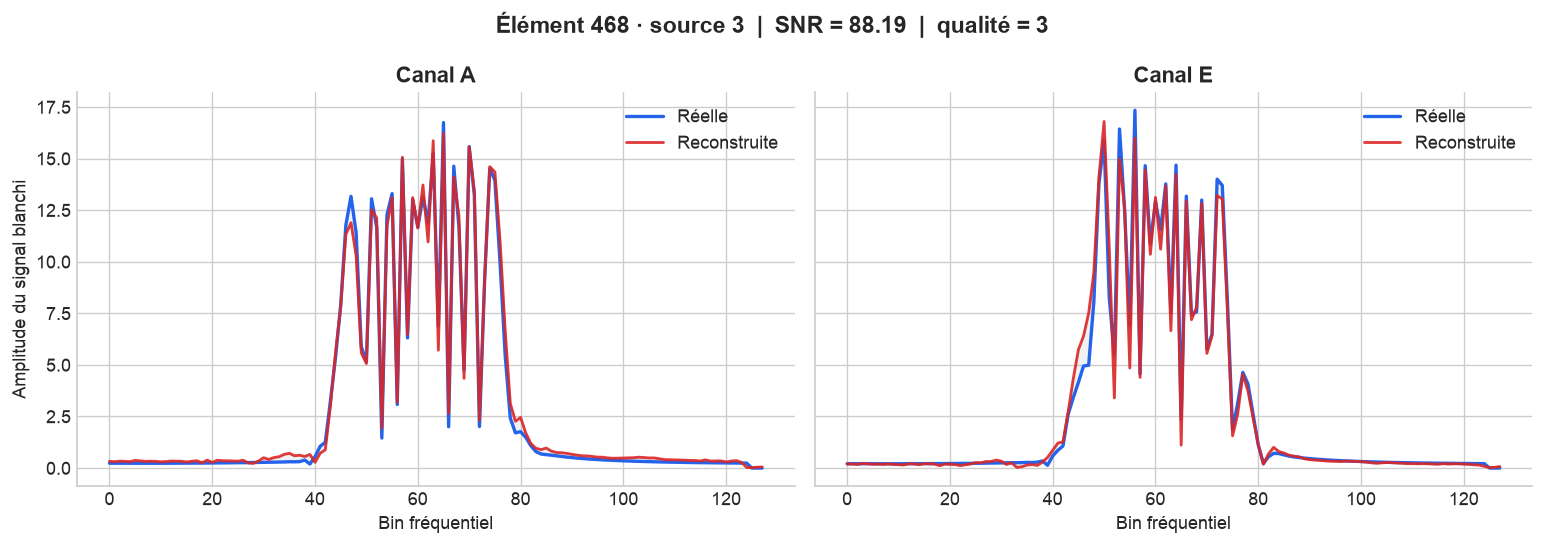

In [5]:
real_a, real_e = complex_channels(source_info["source_real"])
reconstructed_a, reconstructed_e = complex_channels(
    source_info["source_reconstructed"]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
for ax, channel, real_wave, reconstructed_wave in zip(
    axes, ("A", "E"), (real_a, real_e), (reconstructed_a, reconstructed_e)
):
    bins = np.arange(len(real_wave))
    ax.plot(bins, np.abs(real_wave), color=BLUE, lw=2.0, label="Réelle")
    ax.plot(
        bins, np.abs(reconstructed_wave), color=RED, lw=1.7, alpha=0.9,
        label="Reconstruite"
    )
    ax.fill_between(
        bins, np.abs(real_wave), np.abs(reconstructed_wave),
        color="#94A3B8", alpha=0.15
    )
    ax.set(title=f"Canal {channel}", xlabel="Bin fréquentiel")
    ax.legend(frameon=False)
axes[0].set_ylabel("Amplitude du signal blanchi")
fig.suptitle(
    f"Élément {element_index} · source {source_number}  |  "
    f"SNR = {source_info['snr']:.2f}  |  "
    f"qualité = {source_info['reconstruction_quality']}",
    fontsize=14, fontweight="bold",
)
fig.tight_layout()
plt.show()

## 2. Évolution de la log-vraisemblance négative

La ligne représente la médiane des marcheurs et la zone colorée leur intervalle 10–90 %.

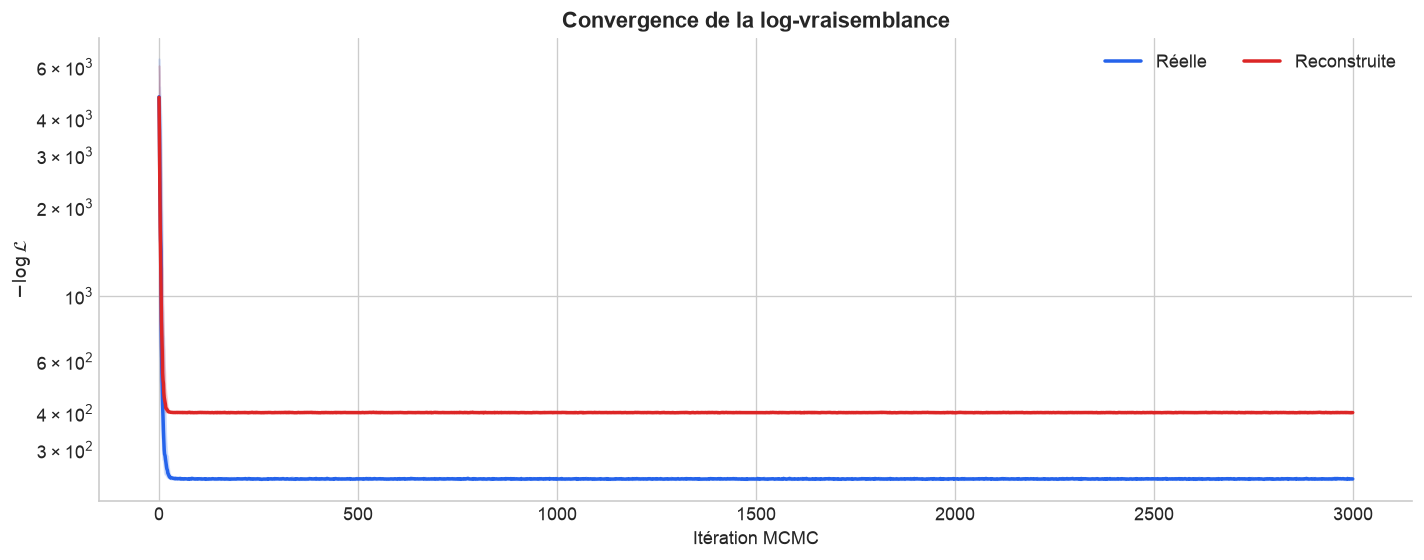

In [6]:
fig, ax = plt.subplots(figsize=(12, 4.8))
steps = np.arange(BURN_IN, n_iterations)
for kind, label in (("real", "Réelle"), ("reconstructed", "Reconstruite")):
    values = clean_negative_log_likelihood(
        posteriors[kind]["log_likelihood"][BURN_IN:]
    )
    median, low, high = median_band(values)
    ax.plot(steps, median, color=COLORS[kind], lw=2.1, label=label)
    ax.fill_between(steps, low, high, color=COLORS[kind], alpha=0.16)
ax.set(
    xlabel="Itération MCMC", ylabel=r"$-\log \mathcal{L}$",
    title="Convergence de la log-vraisemblance"
)
ax.set_yscale("log")
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
plt.show()

## 3. Évolution des paramètres

Comme pour la figure précédente, les lignes sont les médianes des marcheurs et les zones représentent les intervalles 10–90 %. La ligne noire indique la valeur injectée.

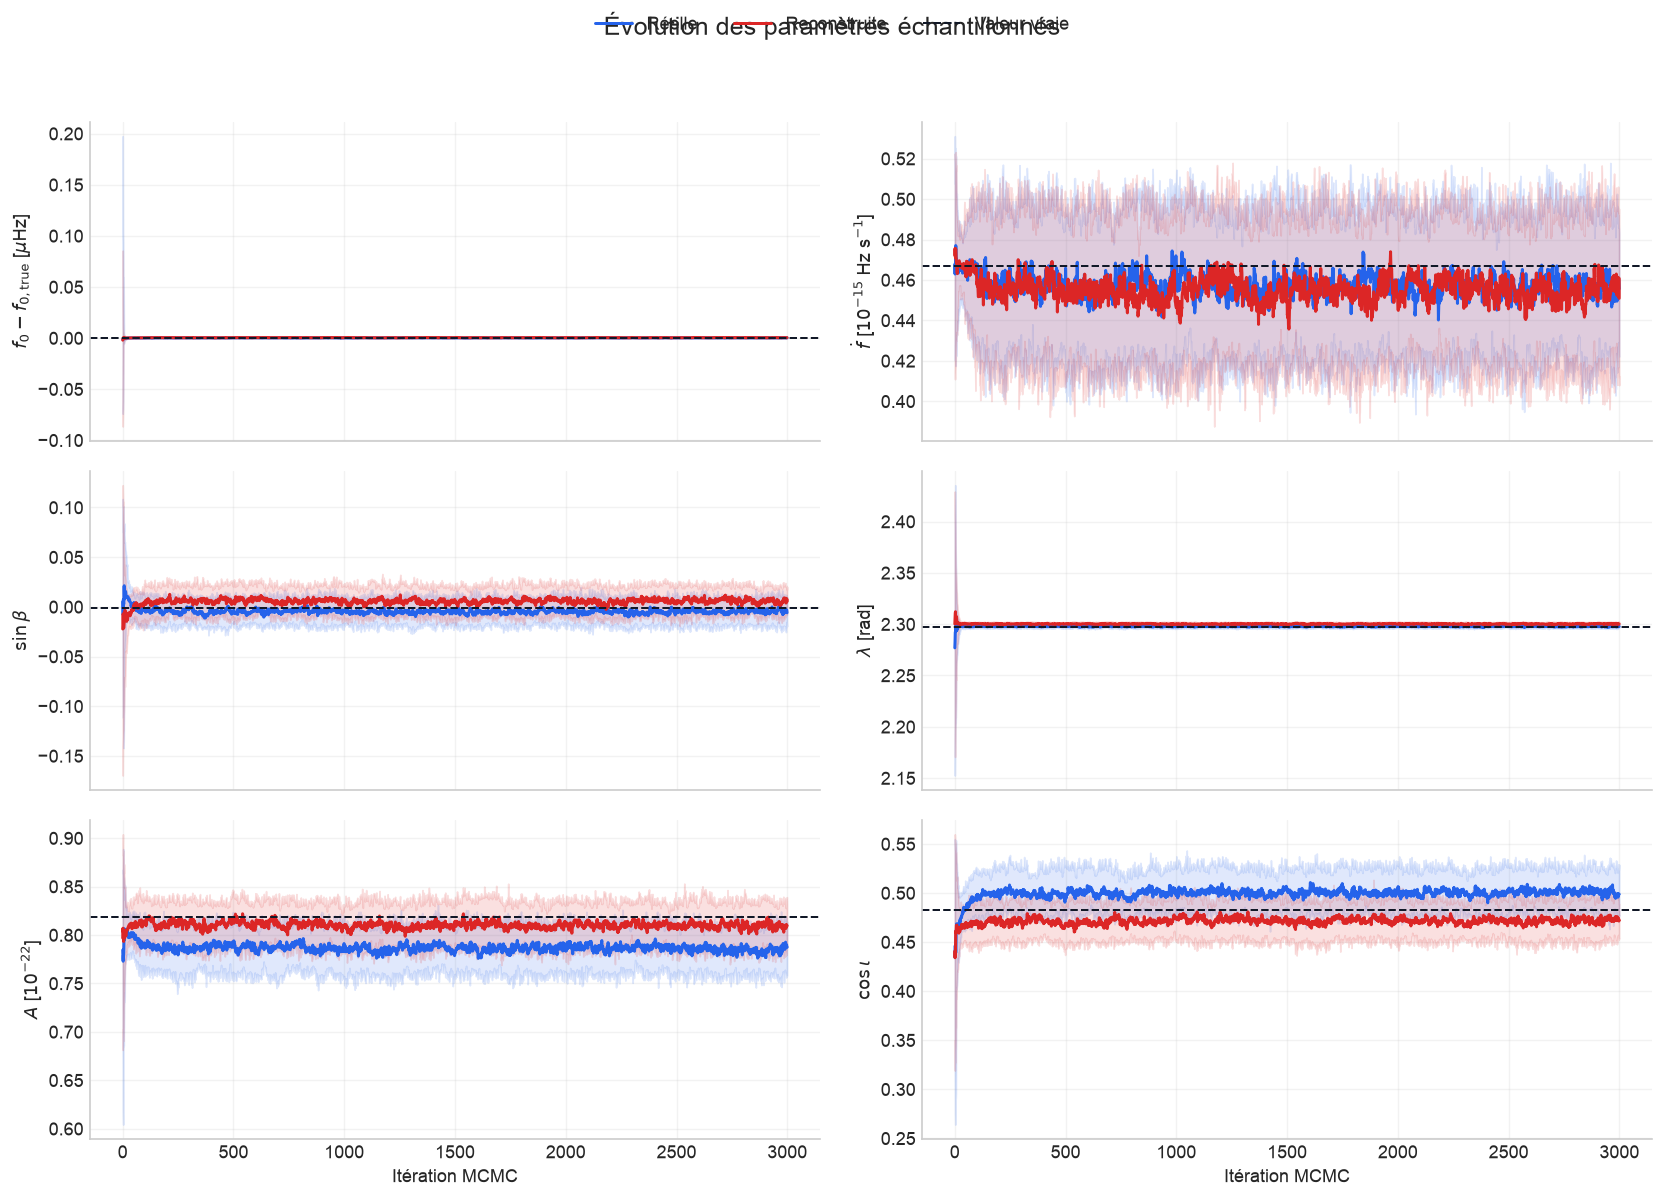

In [7]:
truth_for_plot = transform_parameters(truth, truth[0])
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
axes = axes.ravel()

for parameter_index, ax in enumerate(axes):
    for kind, label in (("real", "Réelle"), ("reconstructed", "Reconstruite")):
        chain = transform_parameters(posteriors[kind]["chain"], truth[0])
        values = chain[BURN_IN:, :, parameter_index]
        median, low, high = median_band(values)
        ax.plot(steps, median, color=COLORS[kind], lw=1.8, label=label)
        ax.fill_between(steps, low, high, color=COLORS[kind], alpha=0.14)
    ax.axhline(
        truth_for_plot[parameter_index], color="#111827", ls="--", lw=1.2,
        label="Valeur vraie"
    )
    ax.set_ylabel(LABELS[parameter_index])
    ax.grid(alpha=0.25)
for ax in axes[-2:]:
    ax.set_xlabel("Itération MCMC")
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="upper center", ncol=3, frameon=False)
fig.suptitle("Évolution des paramètres échantillonnés", y=0.995, fontsize=15)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## 4. Corner plot superposé

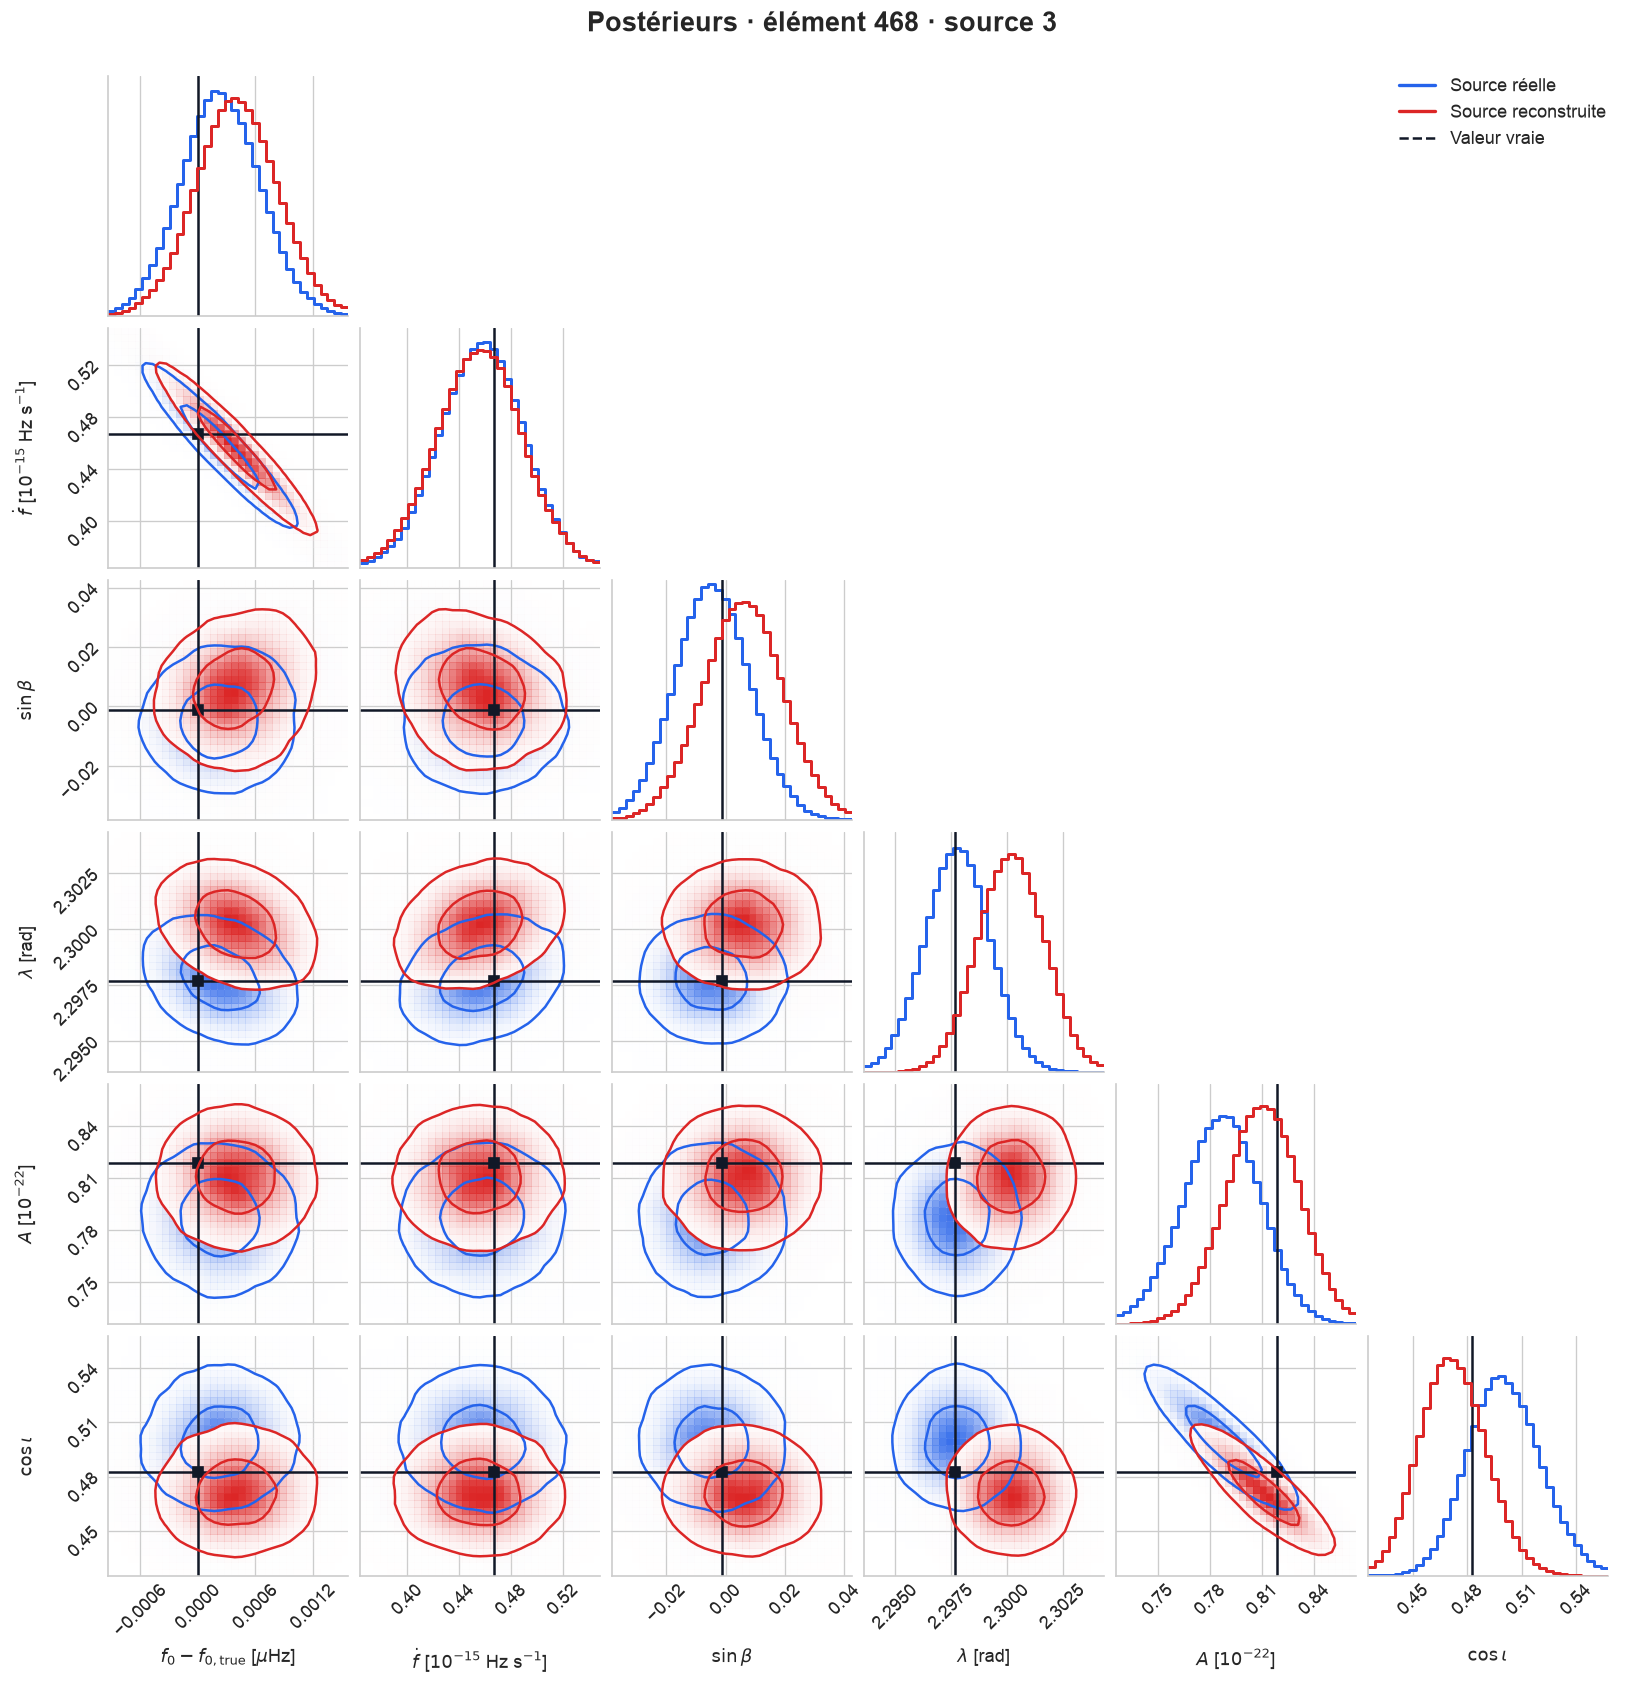

In [8]:
def samples_for_corner(kind):
    samples = posteriors[kind]["chain"][BURN_IN:].reshape(-1, len(LABELS))
    samples = transform_parameters(samples, truth[0])
    if len(samples) > MAX_CORNER_SAMPLES:
        indices = np.linspace(0, len(samples) - 1, MAX_CORNER_SAMPLES, dtype=int)
        samples = samples[indices]
    return samples


real_samples = samples_for_corner("real")
reconstructed_samples = samples_for_corner("reconstructed")
combined = np.vstack((real_samples, reconstructed_samples))
plot_ranges = []
for parameter_index in range(combined.shape[1]):
    low, high = np.quantile(combined[:, parameter_index], [0.005, 0.995])
    padding = 0.05 * (high - low) if high > low else 1.0
    plot_ranges.append((low - padding, high + padding))

figure = corner.corner(
    real_samples, labels=LABELS, truths=truth_for_plot, truth_color="#111827",
    color=BLUE, range=plot_ranges, bins=35, smooth=1.0, smooth1d=1.0,
    plot_datapoints=False, fill_contours=False, levels=(0.393, 0.865),
    hist_kwargs={"linewidth": 1.8},
    contour_kwargs={"linewidths": 1.5},
    label_kwargs={"fontsize": 11},
)
corner.corner(
    reconstructed_samples, fig=figure, color=RED, range=plot_ranges, bins=35,
    smooth=1.0, smooth1d=1.0, plot_datapoints=False, fill_contours=False,
    levels=(0.393, 0.865),
    hist_kwargs={"linewidth": 1.8},
    contour_kwargs={"linewidths": 1.5},
)
figure.legend(
    handles=[
        Line2D([0], [0], color=BLUE, lw=2, label="Source réelle"),
        Line2D([0], [0], color=RED, lw=2, label="Source reconstruite"),
        Line2D([0], [0], color="#111827", ls="--", lw=1.5, label="Valeur vraie"),
    ],
    loc="upper right", bbox_to_anchor=(0.98, 0.98), frameon=False,
)
figure.suptitle(
    f"Postérieurs · élément {element_index} · source {source_number}",
    fontsize=16, fontweight="bold", y=1.01,
)
plt.show()